# 📊 Sales Data Analysis Dashboard
**Dataset:** Retail Sales (Superstore-style) | **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

> **How to use with real Kaggle data:**
> 1. Download [Superstore Sales Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) from Kaggle
> 2. Replace the synthetic data generation cell with: `df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')`
> 3. Map column names if needed (e.g. 'Sales' → 'revenue', 'Profit' → 'profit')

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Style config
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': '#E0E0E0',
    'axes.labelcolor': '#444444',
    'xtick.color': '#666666',
    'ytick.color': '#666666',
    'grid.color': '#F0F0F0',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'blue':   '#378ADD',
    'green':  '#3B6D11',
    'purple': '#7F77DD',
    'amber':  '#EF9F27',
    'coral':  '#D85A30',
    'pink':   '#D4537E',
    'gray':   '#888780',
    'red':    '#E24B4A',
}
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Data Generation (replace with Kaggle CSV for real analysis)

In [2]:
np.random.seed(42)
n = 5000

categories    = ['Electronics', 'Apparel', 'Home & Garden', 'Sports', 'Kitchen']
regions       = ['North', 'South', 'East', 'West']
segments      = ['Champions', 'Loyal Customers', 'At-Risk', 'Potential Loyalists', 'New Customers', 'Hibernating']
seg_weights   = [0.18, 0.22, 0.15, 0.20, 0.13, 0.12]

products = {
    'Electronics':    ['Laptop 15"', 'Wireless Earbuds', 'Smart Watch', 'Tablet Pro', 'Bluetooth Speaker'],
    'Apparel':        ['Running Shoes', 'Winter Jacket', 'Sports T-Shirt', 'Denim Jeans', 'Yoga Pants'],
    'Home & Garden':  ['Office Chair', 'Standing Desk', 'LED Floor Lamp', 'Bookshelf', 'Wall Art Set'],
    'Sports':         ['Yoga Mat', 'Resistance Bands', 'Dumbbell Set', 'Foam Roller', 'Jump Rope'],
    'Kitchen':        ['Blender Pro', 'Air Fryer', 'Coffee Maker', 'Knife Set', 'Food Processor'],
}

cat_arr   = np.random.choice(categories, n, p=[0.25, 0.20, 0.16, 0.22, 0.17])
region_arr = np.random.choice(regions, n, p=[0.30, 0.26, 0.24, 0.20])
seg_arr   = np.random.choice(segments, n, p=seg_weights)

dates = pd.date_range('2023-01-01', '2023-12-31', periods=n)
dates = dates[np.random.randint(0, len(dates), n)]

base_price = {'Electronics': 350, 'Apparel': 80, 'Home & Garden': 200, 'Sports': 55, 'Kitchen': 120}
revenue_arr = np.array([base_price[c] * np.random.uniform(0.7, 2.5) for c in cat_arr])

# Seasonal multiplier
month_mult = {1:0.85, 2:0.80, 3:0.95, 4:1.00, 5:0.92, 6:1.08,
              7:1.18, 8:1.12, 9:1.10, 10:1.25, 11:1.42, 12:1.35}
revenue_arr *= np.array([month_mult[d.month] for d in dates])

margin = {'Electronics': 0.22, 'Apparel': 0.35, 'Home & Garden': 0.28, 'Sports': 0.40, 'Kitchen': 0.30}
profit_arr = np.array([revenue_arr[i] * margin[cat_arr[i]] * np.random.uniform(0.75, 1.25) for i in range(n)])

product_arr = [np.random.choice(products[c]) for c in cat_arr]
quantity_arr = np.random.randint(1, 8, n)

df = pd.DataFrame({
    'order_date': pd.to_datetime(dates),
    'customer_id': [f'CUST{str(i).zfill(4)}' for i in np.random.randint(1, 800, n)],
    'category': cat_arr,
    'product': product_arr,
    'region': region_arr,
    'segment': seg_arr,
    'revenue': revenue_arr.round(2),
    'profit': profit_arr.round(2),
    'quantity': quantity_arr,
})

df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['quarter'] = df['order_date'].dt.quarter
df['profit_margin'] = (df['profit'] / df['revenue'] * 100).round(1)

print(f'✅ Dataset created: {len(df):,} records')
print(f'   Date range : {df.order_date.min().date()} → {df.order_date.max().date()}')
print(f'   Total revenue : ${df.revenue.sum():,.0f}')
print(f'   Total profit  : ${df.profit.sum():,.0f}')
df.head()

✅ Dataset created: 5,000 records
   Date range : 2023-01-01 → 2023-12-31
   Total revenue : $1,488,592
   Total profit  : $392,606


,order_date,customer_id,category,product,region,segment,revenue,profit,quantity,month,month_name,quarter,profit_margin
0,2023-03-09 04:59:17.511502301,CUST0212,Apparel,Running Shoes,South,Loyal Customers,80.23,22.44,5,3,Mar,1,28.0
1,2023-08-11 05:31:15.975195040,CUST0249,Kitchen,Air Fryer,South,Loyal Customers,125.31,45.77,3,8,Aug,3,36.5
2,2023-01-02 02:12:47.673534706,CUST0035,Sports,Yoga Mat,West,Champions,52.35,19.23,4,1,Jan,1,36.7
3,2023-09-19 20:11:16.935387080,CUST0253,Home & Garden,Office Chair,South,Potential Loyalists,408.36,142.78,2,9,Sep,3,35.0
4,2023-06-24 23:21:41.300260054,CUST0772,Electronics,Tablet Pro,West,At-Risk,574.43,156.62,1,6,Jun,2,27.3


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== DATASET OVERVIEW ===')
print(df.info())
print('\n=== NULL VALUES ===')
print(df.isnull().sum())
print('\n=== BASIC STATISTICS ===')
df[['revenue','profit','quantity','profit_margin']].describe().round(2)

=== DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_date     5000 non-null   datetime64[ns]
 1   customer_id    5000 non-null   object        
 2   category       5000 non-null   object        
 3   product        5000 non-null   object        
 4   region         5000 non-null   object        
 5   segment        5000 non-null   object        
 6   revenue        5000 non-null   float64       
 7   profit         5000 non-null   float64       
 8   quantity       5000 non-null   int32         
 9   month          5000 non-null   int32         
 10  month_name     5000 non-null   object        
 11  quarter        5000 non-null   int32         
 12  profit_margin  5000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(3), object(6)
memory usage: 449.3+ KB
None

=== NULL VALUE

,revenue,profit,quantity,profit_margin
count,5000.00,5000.00,5000.00,5000.00
mean,297.72,78.52,3.97,30.83
std,247.43,51.75,2.00,8.07
min,32.45,10.26,1.00,16.50
25%,113.64,40.88,2.00,24.30
50%,202.15,62.83,4.00,30.40
75%,411.80,102.90,6.00,36.60
max,1232.46,295.74,7.00,50.00


## 4. KPI Summary

In [4]:
total_revenue  = df['revenue'].sum()
total_profit   = df['profit'].sum()
total_orders   = len(df)
avg_order_val  = df['revenue'].mean()
avg_margin     = (total_profit / total_revenue * 100)
unique_customers = df['customer_id'].nunique()

print('━' * 50)
print(f'  💰 Total Revenue     : ${total_revenue:>12,.2f}')
print(f'  📈 Total Profit      : ${total_profit:>12,.2f}')
print(f'  🛒 Total Orders      : {total_orders:>13,}')
print(f'  🧾 Avg Order Value   : ${avg_order_val:>12,.2f}')
print(f'  📊 Profit Margin     : {avg_margin:>12.1f}%')
print(f'  👥 Unique Customers  : {unique_customers:>13,}')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💰 Total Revenue     : $1,488,592.04
  📈 Total Profit      : $  392,606.45
  🛒 Total Orders      :         5,000
  🧾 Avg Order Value   : $      297.72
  📊 Profit Margin     :         26.4%
  👥 Unique Customers  :           797
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 5. Monthly Revenue & Profit Trend

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/chart_trend.png'

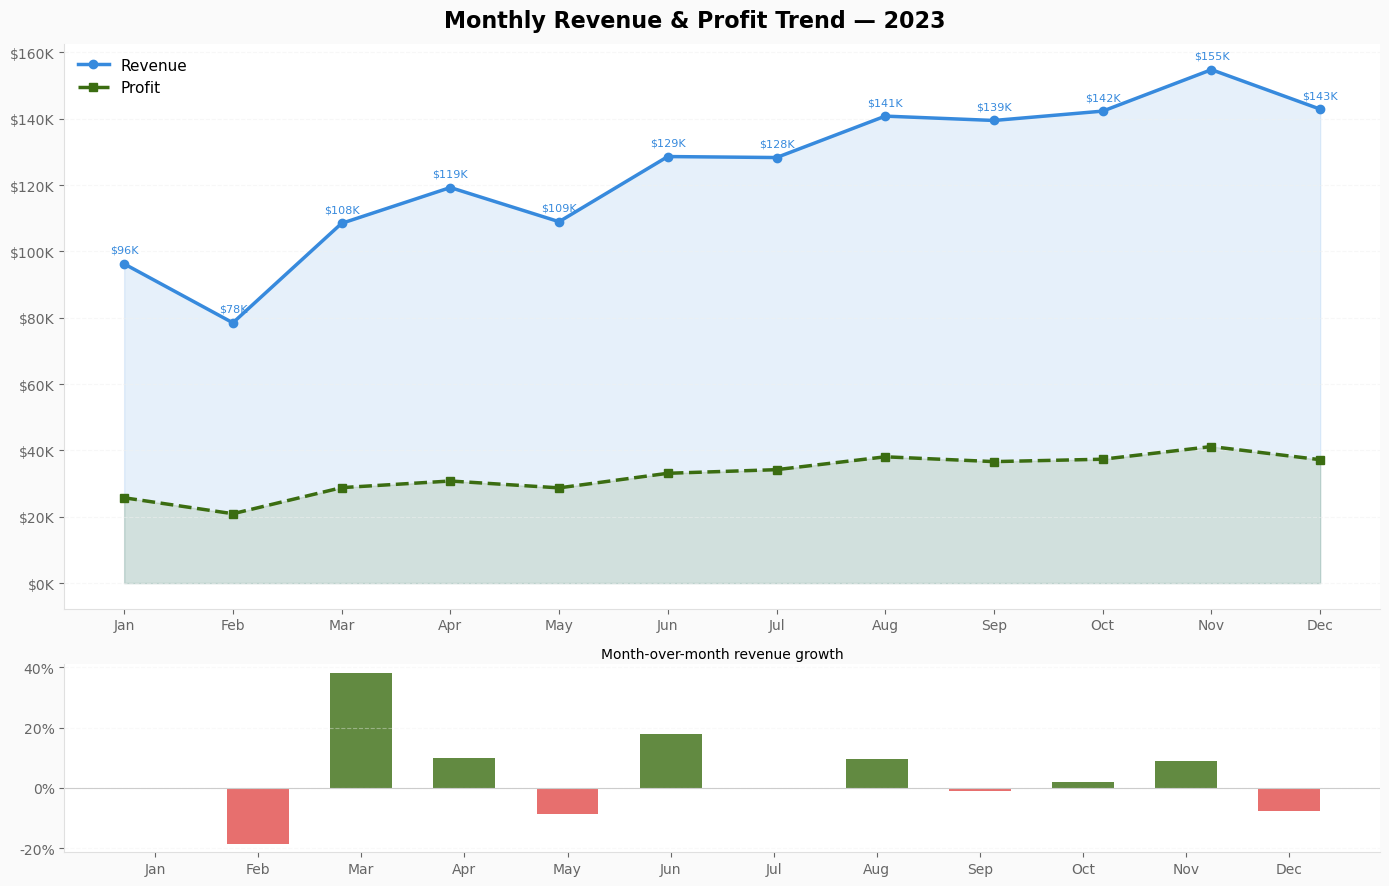

In [5]:
monthly = df.groupby('month').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('revenue','count')
).reset_index()
monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')
monthly['revenue_growth'] = monthly['revenue'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3,1])
fig.suptitle('Monthly Revenue & Profit Trend — 2023', fontsize=16, fontweight='bold', y=0.98)

ax = axes[0]
x = range(len(monthly))
ax.fill_between(x, monthly['revenue'], alpha=0.12, color=COLORS['blue'])
ax.plot(x, monthly['revenue'], color=COLORS['blue'], linewidth=2.5, marker='o', markersize=6, label='Revenue')
ax.fill_between(x, monthly['profit'], alpha=0.12, color=COLORS['green'])
ax.plot(x, monthly['profit'], color=COLORS['green'], linewidth=2.5, marker='s', markersize=6, linestyle='--', label='Profit')
ax.set_xticks(x); ax.set_xticklabels(monthly['month_name'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.legend(frameon=False, fontsize=11); ax.grid(True, axis='y', alpha=0.5)
for i, row in monthly.iterrows():
    ax.annotate(f'${row.revenue/1000:.0f}K', (i, row.revenue), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8, color=COLORS['blue'])

# Revenue growth bar
ax2 = axes[1]
growth = monthly['revenue_growth'].fillna(0)
bars = ax2.bar(x, growth, color=[COLORS['green'] if v>=0 else COLORS['red'] for v in growth], alpha=0.8, width=0.6)
ax2.axhline(0, color='#cccccc', linewidth=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(monthly['month_name'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax2.set_title('Month-over-month revenue growth', fontsize=10, pad=4)
ax2.grid(True, axis='y', alpha=0.4)

plt.tight_layout(); plt.savefig('/home/claude/chart_trend.png', dpi=150, bbox_inches='tight'); plt.show()
print('✅ Saved chart_trend.png')

## 6. Top-Selling Products

In [ ]:
top_products = df.groupby('product').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    units=('quantity','sum'),
    orders=('revenue','count')
).sort_values('revenue', ascending=False).head(10).reset_index()
top_products['margin_pct'] = (top_products['profit'] / top_products['revenue'] * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top Products Analysis', fontsize=16, fontweight='bold')

# Revenue bars
bars = ax1.barh(top_products['product'], top_products['revenue']/1000, color=COLORS['blue'], alpha=0.85)
ax1.set_xlabel('Revenue ($ thousands)')
ax1.set_title('Revenue by product (top 10)', fontsize=12)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
for bar, val in zip(bars, top_products['revenue']):
    ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'${val/1000:.0f}K', va='center', fontsize=9)

# Profit margin scatter
scatter = ax2.scatter(top_products['revenue']/1000, top_products['margin_pct'],
                      s=top_products['units']/2, c=top_products['profit']/1000,
                      cmap='YlGn', alpha=0.8, edgecolors='#333', linewidth=0.5)
plt.colorbar(scatter, ax=ax2, label='Profit ($K)')
ax2.set_xlabel('Revenue ($K)'); ax2.set_ylabel('Profit margin (%)')
ax2.set_title('Revenue vs margin (bubble = units sold)', fontsize=12)
for _, row in top_products.iterrows():
    ax2.annotate(row['product'].split()[0], (row['revenue']/1000, row['margin_pct']),
                 fontsize=8, ha='center', va='bottom', xytext=(0,6), textcoords='offset points')

plt.tight_layout(); plt.savefig('/home/claude/chart_products.png', dpi=150, bbox_inches='tight'); plt.show()
print(top_products[['product','revenue','profit','margin_pct','units']].to_string(index=False))

## 7. Regional Analysis

In [ ]:
regional = df.groupby('region').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('revenue','count'),
    customers=('customer_id','nunique')
).reset_index()
regional['margin'] = (regional['profit'] / regional['revenue'] * 100).round(1)
regional['rev_share'] = (regional['revenue'] / regional['revenue'].sum() * 100).round(1)
regional = regional.sort_values('revenue', ascending=False)

region_monthly = df.groupby(['region','month'])['revenue'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Regional Sales Analysis', fontsize=16, fontweight='bold')

reg_colors = [COLORS['blue'], COLORS['purple'], COLORS['amber'], COLORS['coral']]

# Donut
wedges, texts, autotexts = axes[0].pie(
    regional['revenue'], labels=regional['region'], autopct='%1.1f%%',
    colors=reg_colors, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
axes[0].set_title('Revenue share by region', fontsize=12)

# Bar comparison
x = np.arange(len(regional))
w = 0.35
axes[1].bar(x - w/2, regional['revenue']/1000, w, color=COLORS['blue'], label='Revenue', alpha=0.85)
axes[1].bar(x + w/2, regional['profit']/1000, w, color=COLORS['green'], label='Profit', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(regional['region'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
axes[1].set_title('Revenue vs profit by region', fontsize=12)
axes[1].legend(frameon=False); axes[1].grid(True, axis='y', alpha=0.4)

# Monthly trend per region
months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
for i, (reg, color) in enumerate(zip(region_monthly.index, reg_colors)):
    axes[2].plot(range(12), region_monthly.loc[reg]/1000, color=color, linewidth=2, marker='o', markersize=4, label=reg)
axes[2].set_xticks(range(12)); axes[2].set_xticklabels(months_labels)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
axes[2].set_title('Monthly trend by region', fontsize=12)
axes[2].legend(frameon=False, fontsize=9); axes[2].grid(True, alpha=0.4)

plt.tight_layout(); plt.savefig('/home/claude/chart_regional.png', dpi=150, bbox_inches='tight'); plt.show()
print(regional[['region','revenue','profit','margin','orders','rev_share']].to_string(index=False))

## 8. Category & Profit Analysis

In [ ]:
cat_data = df.groupby('category').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    units=('quantity','sum'),
    orders=('revenue','count')
).reset_index()
cat_data['margin'] = (cat_data['profit'] / cat_data['revenue'] * 100).round(1)
cat_data = cat_data.sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Category Performance & Profit Analysis', fontsize=16, fontweight='bold')

cat_colors = [COLORS['blue'], COLORS['purple'], COLORS['amber'], COLORS['coral'], COLORS['green']]

# Stacked bar
x = range(len(cat_data))
axes[0].bar(x, cat_data['profit']/1000, color=COLORS['green'], label='Profit', alpha=0.9)
axes[0].bar(x, (cat_data['revenue']-cat_data['profit'])/1000, bottom=cat_data['profit']/1000,
            color=COLORS['blue'], label='Cost', alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(cat_data['category'], rotation=15, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
axes[0].set_title('Revenue breakdown (profit vs cost)', fontsize=11)
axes[0].legend(frameon=False); axes[0].grid(True, axis='y', alpha=0.4)

# Profit margin
bars = axes[1].bar(x, cat_data['margin'], color=cat_colors, alpha=0.85, width=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels(cat_data['category'], rotation=15, ha='right', fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
axes[1].set_title('Profit margin by category', fontsize=11)
axes[1].axhline(cat_data['margin'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Avg {cat_data["margin"].mean():.1f}%')
axes[1].legend(frameon=False)
for bar, val in zip(bars, cat_data['margin']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Quarterly heatmap data
pivot = df.pivot_table(values='revenue', index='category', columns='quarter', aggfunc='sum')
pivot.columns = ['Q1','Q2','Q3','Q4']
norm = pivot.div(pivot.max(axis=1), axis=0)
im = axes[2].imshow(norm.values, cmap='Blues', aspect='auto')
axes[2].set_xticks([0,1,2,3]); axes[2].set_xticklabels(['Q1','Q2','Q3','Q4'])
axes[2].set_yticks(range(len(pivot))); axes[2].set_yticklabels(pivot.index, fontsize=9)
axes[2].set_title('Seasonal revenue heatmap\n(normalized per category)', fontsize=11)
for i in range(len(pivot)):
    for j in range(4):
        axes[2].text(j, i, f'${pivot.iloc[i,j]/1000:.0f}K', ha='center', va='center', fontsize=8,
                     color='white' if norm.iloc[i,j] > 0.7 else '#333')

plt.tight_layout(); plt.savefig('/home/claude/chart_category.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Customer Segmentation (RFM Analysis)

In [ ]:
# RFM Calculation
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_date', 'count'),
    monetary=('revenue', 'sum')
).reset_index()

# Score each dimension 1-5
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

def segment_customer(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4: return 'Champions'
    elif row['r_score'] >= 3 and row['f_score'] >= 3: return 'Loyal Customers'
    elif row['r_score'] >= 4 and row['f_score'] <= 2: return 'Potential Loyalists'
    elif row['r_score'] <= 2 and row['f_score'] >= 3: return 'At-Risk'
    elif row['r_score'] == 5 and row['f_score'] == 1: return 'New Customers'
    else: return 'Hibernating'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

seg_summary = rfm.groupby('segment').agg(
    count=('customer_id','count'),
    avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean')
).round(1).reset_index()
seg_summary['pct'] = (seg_summary['count'] / seg_summary['count'].sum() * 100).round(1)

seg_colors_map = {
    'Champions': COLORS['blue'], 'Loyal Customers': COLORS['purple'],
    'At-Risk': COLORS['red'], 'Potential Loyalists': COLORS['amber'],
    'New Customers': COLORS['green'], 'Hibernating': COLORS['gray']
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Segmentation — RFM Analysis', fontsize=16, fontweight='bold')

# Donut
colors_list = [seg_colors_map.get(s, COLORS['gray']) for s in seg_summary['segment']]
axes[0].pie(seg_summary['count'], labels=seg_summary['segment'], autopct='%1.1f%%',
            colors=colors_list, startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
axes[0].set_title('Customer distribution by segment', fontsize=11)

# Avg monetary
seg_sorted = seg_summary.sort_values('avg_monetary', ascending=True)
bar_colors = [seg_colors_map.get(s, COLORS['gray']) for s in seg_sorted['segment']]
bars = axes[1].barh(seg_sorted['segment'], seg_sorted['avg_monetary'], color=bar_colors, alpha=0.85)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))
axes[1].set_title('Avg revenue per customer\nby segment', fontsize=11)
for bar, val in zip(bars, seg_sorted['avg_monetary']):
    axes[1].text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, f'${val:.0f}', va='center', fontsize=9)

# R vs F scatter
colors_rfm = [seg_colors_map.get(s, COLORS['gray']) for s in rfm['segment']]
axes[2].scatter(rfm['frequency'], rfm['recency'], c=colors_rfm, alpha=0.4, s=30, linewidths=0)
axes[2].set_xlabel('Frequency (# orders)'); axes[2].set_ylabel('Recency (days since last order)')
axes[2].set_title('RFM scatter: frequency vs recency', fontsize=11)
patches = [mpatches.Patch(color=v, label=k) for k,v in seg_colors_map.items()]
axes[2].legend(handles=patches, frameon=False, fontsize=8, loc='upper right')

plt.tight_layout(); plt.savefig('/home/claude/chart_segments.png', dpi=150, bbox_inches='tight'); plt.show()
print(seg_summary[['segment','count','pct','avg_recency','avg_frequency','avg_monetary']].to_string(index=False))

## 10. Revenue Growth & Seasonal Trends

In [ ]:
quarterly = df.groupby(['quarter','category'])['revenue'].sum().unstack(fill_value=0)
q_total = df.groupby('quarter')['revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonal Trends & Revenue Growth', fontsize=16, fontweight='bold')

# Stacked quarterly
bottom = np.zeros(4)
for cat, color in zip(quarterly.columns, cat_colors):
    axes[0].bar(['Q1','Q2','Q3','Q4'], quarterly[cat]/1000, bottom=bottom/1000, label=cat, color=color, alpha=0.85)
    bottom += quarterly[cat].values
axes[0].set_title('Quarterly revenue by category', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
axes[0].legend(frameon=False, fontsize=9, loc='upper left'); axes[0].grid(True, axis='y', alpha=0.4)

# Growth waterfall
q_vals = q_total.values
q_growth = np.diff(q_vals)
labels = ['Q1 base', 'Q1→Q2', 'Q2→Q3', 'Q3→Q4']
values = [q_vals[0]] + list(q_growth)
running = np.cumsum([0] + list(values))
bar_colors_wf = [COLORS['blue']] + [COLORS['green'] if v >= 0 else COLORS['red'] for v in q_growth]
bars = axes[1].bar(labels, [abs(v) for v in values], bottom=[0]+list(running[:-1]),
                   color=bar_colors_wf, alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    sign = '+' if val >= 0 else ''
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_y()+bar.get_height()+500,
                f'{sign}${val/1000:.1f}K', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Quarterly revenue growth waterfall', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
axes[1].grid(True, axis='y', alpha=0.4)

plt.tight_layout(); plt.savefig('/home/claude/chart_seasonal.png', dpi=150, bbox_inches='tight'); plt.show()

## 11. Export Data for Power BI / Tableau

In [ ]:
with pd.ExcelWriter('/home/claude/sales_analysis_export.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    monthly.to_excel(writer, sheet_name='Monthly Trends', index=False)
    regional.to_excel(writer, sheet_name='Regional Analysis', index=False)
    cat_data.to_excel(writer, sheet_name='Category Performance', index=False)
    top_products.to_excel(writer, sheet_name='Top Products', index=False)
    rfm.to_excel(writer, sheet_name='RFM Segmentation', index=False)
    seg_summary.to_excel(writer, sheet_name='Segment Summary', index=False)

print('✅ Excel file exported: sales_analysis_export.xlsx')
print('   Sheets: Raw Data, Monthly Trends, Regional Analysis,')
print('           Category Performance, Top Products, RFM Segmentation, Segment Summary')

---
## ✅ Analysis Complete
All charts saved. Run `generate_pdf_report.py` to compile them into a PDF report.

**To connect to Power BI:** Use `sales_analysis_export.xlsx` as the data source.

**GitHub README tip:** Add your chart PNGs (`chart_*.png`) to the repo for a visual preview!